In [522]:
import random
import datetime

In [520]:

# 1. Criar dados simulados para ordens

orders = []
base_price = 280
for i in range(100):
    price = base_price - i*2 + random.randint(-5, 5)  # tendência de alta 
    order = {
        "type": random.choice(["buy", "sell"]),
        "price": price,
        "amount": random.randint(50, 505),
        "maximum": price + random.randint(20, 50),
        "minimum": price - random.randint(20, 50),
        "volume": random.randint(800, 2000),
        "time": datetime.datetime.now() + datetime.timedelta(seconds=i)
    }
    orders.append(order)

# Visualizar preços simulados
prices = [o["price"] for o in orders]
print(prices)

[283, 279, 280, 278, 271, 266, 268, 268, 267, 262, 261, 263, 256, 258, 251, 253, 247, 242, 247, 242, 243, 235, 236, 232, 234, 226, 224, 227, 227, 217, 222, 221, 217, 215, 211, 212, 207, 205, 203, 199, 199, 193, 195, 191, 192, 189, 188, 182, 188, 183, 183, 177, 171, 178, 173, 165, 164, 161, 169, 159, 165, 156, 153, 158, 147, 154, 143, 141, 149, 140, 136, 137, 135, 136, 130, 130, 125, 124, 129, 124, 118, 113, 121, 114, 112, 115, 109, 107, 102, 107, 102, 100, 94, 94, 89, 94, 91, 81, 80, 78]


In [142]:
#pegar o último preço e tempo
last_order = orders[-1]
price_current = last_order["price"]
time_current = last_order["time"]

print("Último preço:", price_current)
print("Tempo da última ordem:", time_current)

Último preço: 101
Tempo da última ordem: 2026-09-30 02:00:27.360160


In [256]:
# ===============Função de onda Ψ=============== #
# 1. Separar ordens de compra e venda
def wave_function(orders):
    buy = [o["amount"] for o in orders if o["type"] == "buy"]
    sell = [o["amount"] for o in orders if o["type"] == "sell"]


    # 2. Calcular médias
    media_buy = sum(buy) / len(buy) if buy else 0
    media_sell = sum(sell) / len(sell) if sell else 0

    # 3. Calcular probabilidades
    higher_probability_buy = sum(1 for q in buy if q > media_buy) / len(buy) if buy else 0
    higher_probability_sell = sum(1 for q in sell if q > media_sell) / len(sell) if sell else 0

    return {
             "buy": higher_probability_buy,
             "sell":higher_probability_sell
            }

higher_probability = wave_function(orders)
print("Probabilidade ordem de compra > média:",higher_probability.get("buy"))
print("Probabilidade ordem de venda > média:",higher_probability.get("sell"))

Probabilidade ordem de compra > média: 0.5555555555555556
Probabilidade ordem de venda > média: 0.5833333333333334


In [549]:
# Função para calcular - Energia cinética (velocidade do preço)
def calculate_kinetic_energy(orders):
    energy = []
    for i in range(1, len(orders)):
        price_current = orders[i]["price"]
        price_previous = orders[i-1]["price"]
        time_current = orders[i]["time"]
        time_previous = orders[i-1]["time"]
        vol_current = orders[i]["volume"]

        # ΔP e Δt
        delta_price = price_current - price_previous
        delta_time = (time_current - time_previous).total_seconds()

        # Energia cinética ~ (vol * ΔP^2 / Δt)
        if delta_time > 0:
            e_c = (vol_current * delta_price **2) / delta_time
            energy.append(e_c)
        else:                        
            energy.append(0)

    return energy

energy_kinetic = calculate_kinetic_energy(orders)

# Mostrar resultados
for i, e in enumerate(energy_kinetic, start=1):
    print(f"Ordem {i}: Energia cinética = {e}")

        

Ordem 1: Energia cinética = 26143.29413105846
Ordem 2: Energia cinética = 1216.9866131472554
Ordem 3: Energia cinética = 5547.950068449384
Ordem 4: Energia cinética = 65904.53866822932
Ordem 5: Energia cinética = 37749.69800241598
Ordem 6: Energia cinética = 6655.9534083261415
Ordem 7: Energia cinética = 0.0
Ordem 8: Energia cinética = 1540.9892130755084
Ordem 9: Energia cinética = 46749.67275229073
Ordem 10: Energia cinética = 1031.9927760505675
Ordem 11: Energia cinética = 6743.959536242783
Ordem 12: Energia cinética = 68403.45277237782
Ordem 13: Energia cinética = 4951.965336242646
Ordem 14: Energia cinética = 45618.68066923531
Ordem 15: Energia cinética = 4923.965532241274
Ordem 16: Energia cinética = 56231.60637875534
Ordem 17: Energia cinética = 43724.69392714251
Ordem 18: Energia cinética = 32024.743802049583
Ordem 19: Energia cinética = 40624.715626990605
Ordem 20: Energia cinética = 1226.9914110601226
Ordem 21: Energia cinética = 114431.31341211953
Ordem 22: Energia cinética =

In [ ]:
#Função para calcular energia potencial
def calculate_Potential_energy(orders, max_expansao_pct=0.3):
    if not orders:
        return []

    p_min = orders[0]["price"]
    p_max = orders[0]["price"]
    track_volume = 0
    energies = []

    for o in orders:
        price = o["price"]
        vol = o["volume"]

        nova_min = min(p_min, price)
        nova_max = max(p_max, price)
        amplitude_atual = p_max - p_min
        amplitude_nova = nova_max - nova_min

        # Se a expansão for pequena → ainda é consolidação
        if amplitude_atual == 0 or (amplitude_nova - amplitude_atual) / max(amplitude_atual, 1e-9) <= max_expansao_pct:
            p_min, p_max = nova_min, nova_max
            track_volume += vol
            e_p = (p_max - p_min) * track_volume
            energies.append(e_p)
        else:
            # Rompeu → fecha a consolidação e reinicia
            energies.append(0)
            p_min = p_max = price
            track_volume = vol

    return energies


# Calcular energia potencial
potential_energy = calculate_Potential_energy(orders)

# Mostrar resultados
for i, e in enumerate(potential_energy, start=1):
    print(f"Ordem {i}: Energia potencial = {e}")


Ordem 1: Energia potencial = 0
Ordem 2: Energia potencial = 11180
Ordem 3: Energia potencial = 16048
Ordem 4: Energia potencial = 26995
Ordem 5: Energia potencial = -17485
Ordem 6: Energia potencial = -27180
Ordem 7: Energia potencial = 53958
Ordem 8: Energia potencial = 75344
Ordem 9: Energia potencial = 101541
Ordem 10: Energia potencial = 164703
Ordem 11: Energia potencial = 195250
Ordem 12: Energia potencial = 232342
Ordem 13: Energia potencial = 322839
Ordem 14: Energia potencial = 356265
Ordem 15: Energia potencial = 452032
Ordem 16: Energia potencial = 491424
Ordem 17: Energia potencial = 609084
Ordem 18: Energia potencial = 765388
Ordem 19: Energia potencial = 817909
Ordem 20: Energia potencial = 884534
Ordem 21: Energia potencial = 934841
Ordem 22: Energia potencial = 1180272
Ordem 23: Energia potencial = 1220784
Ordem 24: Energia potencial = 1364454
Ordem 25: Energia potencial = 1460895
Ordem 26: Energia potencial = 1728924
Ordem 27: Energia potencial = 1904992
Ordem 28: Ener

In [296]:
# Constante de Planck
def calculate_planck_constant(orders, alpha=0.1):
    # Extrair volumes
    volumes = [o["volume"] for o in orders]
    
    # Calcular média exponencial (EMA)
    ema = [volumes[0]]
    for v in volumes[1:]:
        ema.append(alpha * v + (1 - alpha) * ema[-1])
    
    # Constante de Planck do mercado = último valor da EMA
    h_market = ema[-1]
    return h_market, ema

h_market, ema_series = calculate_planck_constant(orders)

print("Constante de Planck (mercado):", h_market)

Constante de Planck (mercado): 1291.8409733553103


In [579]:
# Evolução de função de onda
def evolve_wave_function(orders, h_market):
    # Função de onda inicial
    psi = wave_function(orders)
    psi_buy = psi["buy"]
    psi_sell = psi["sell"]

    kinetic = calculate_kinetic_energy(orders)
    potential = calculate_Potential_energy(orders)

    evolution = []
    for i in range(min(len(kinetic), len(potential))):
        H = kinetic[i] + potential[i]
        price_current = orders[i]["price"]
        price_previous = orders[i-1]["price"] if i > 0 else price_current

        # Drift proporcional à variação de preço
        drift = (price_current - price_previous) / max(price_previous,1)

        # Oscilação senoidal (interferência quântica)
        oscillation = 0.05 * np.sin(i * 0.3)  # amplitude 0.05, frequência 0.3

        # Atualização com viés + oscilação
        psi_buy += (H / h_market) * 0.1 * (1 + drift) + oscillation
        psi_sell += (H / h_market) * 0.1 * (1 - drift) - oscillation

        # Normalização
        total = psi_buy + psi_sell
        psi_buy /= total
        psi_sell /= total

        # Limitar entre 0 e 1
        psi_buy = max(0, min(1, psi_buy))
        psi_sell = max(0, min(1, psi_sell))

        evolution.append({"ordem": i+1, "psi_buy": psi_buy, "psi_sell": psi_sell, "H": H, "oscillation": oscillation})

    return evolution

# Evoluir função de onda
evolution_series = evolve_wave_function(orders, h_market)


# Mostrar resultados
for e in evolution_series:
    print(f"Ordem {e['ordem']}: Ψ_buy={e['psi_buy']:.4f}, Ψ_sell={e['psi_sell']:.4f}, H={e['H']:.2f}")


Ordem 1: Ψ_buy=0.5021, Ψ_sell=0.4979, H=26143.29
Ordem 2: Ψ_buy=0.5011, Ψ_sell=0.4989, H=12396.99
Ordem 3: Ψ_buy=0.5081, Ψ_sell=0.4919, H=21595.95
Ordem 4: Ψ_buy=0.4997, Ψ_sell=0.5003, H=92899.54
Ordem 5: Ψ_buy=0.4960, Ψ_sell=0.5040, H=37749.70
Ordem 6: Ψ_buy=0.5038, Ψ_sell=0.4962, H=20930.95
Ordem 7: Ψ_buy=0.5146, Ψ_sell=0.4854, H=22595.00
Ordem 8: Ψ_buy=0.5101, Ψ_sell=0.4899, H=30425.99
Ordem 9: Ψ_buy=0.5014, Ψ_sell=0.4986, H=83339.67
Ordem 10: Ψ_buy=0.5184, Ψ_sell=0.4816, H=1031.99
Ordem 11: Ψ_buy=0.5091, Ψ_sell=0.4909, H=9645.96
Ordem 12: Ψ_buy=0.5036, Ψ_sell=0.4964, H=68403.45
Ordem 13: Ψ_buy=0.4857, Ψ_sell=0.5143, H=26525.97
Ordem 14: Ψ_buy=0.4998, Ψ_sell=0.5002, H=75858.68
Ordem 15: Ψ_buy=0.4693, Ψ_sell=0.5307, H=4923.97
Ordem 16: Ψ_buy=0.4959, Ψ_sell=0.5041, H=60555.61
Ordem 17: Ψ_buy=0.4827, Ψ_sell=0.5173, H=43724.69
Ordem 18: Ψ_buy=0.4836, Ψ_sell=0.5164, H=48579.74
Ordem 19: Ψ_buy=0.5043, Ψ_sell=0.4957, H=63584.72
Ordem 20: Ψ_buy=0.4877, Ψ_sell=0.5123, H=32311.99
Ordem 21: Ψ_

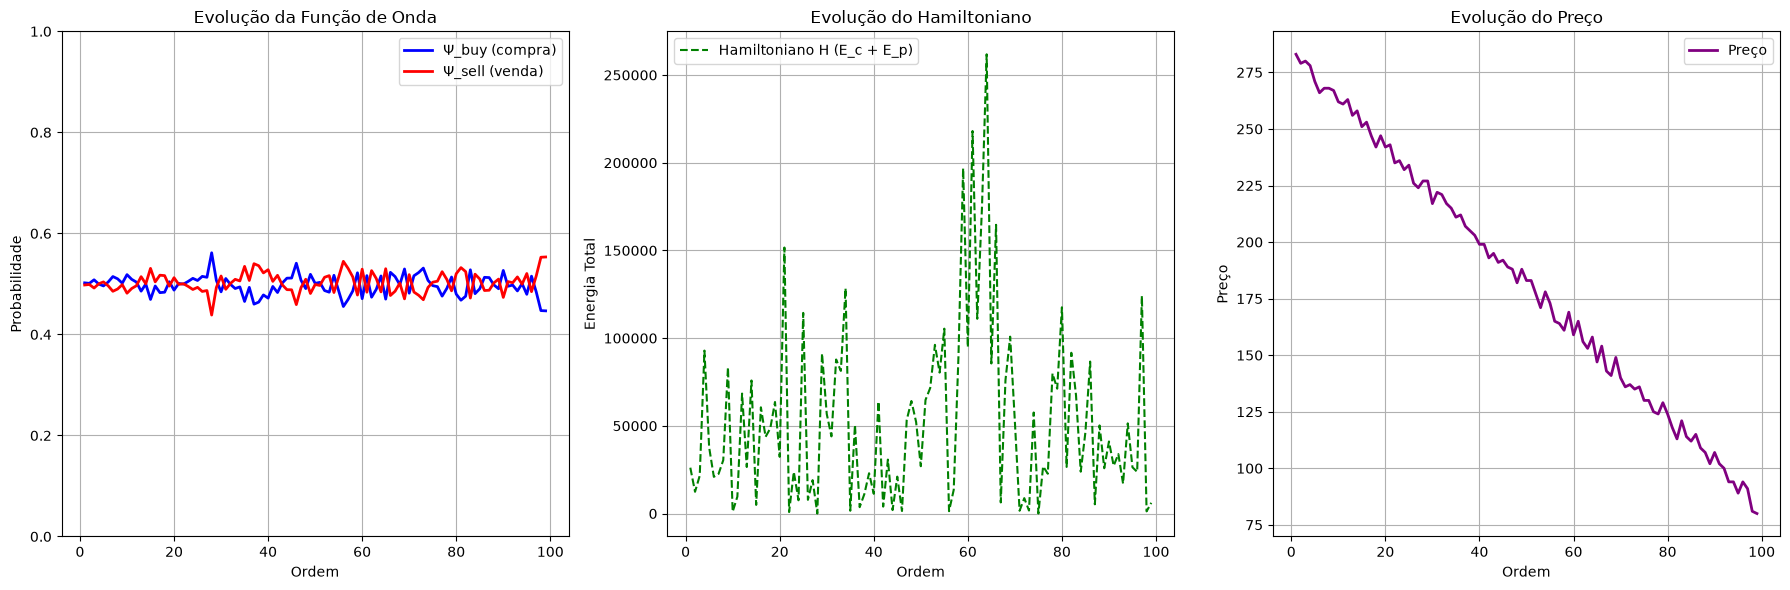

In [580]:
import matplotlib.pyplot as plt

# Extrair dados
ordens = [e["ordem"] for e in evolution_series]
psi_buy = [e["psi_buy"] for e in evolution_series]
psi_sell = [e["psi_sell"] for e in evolution_series]
hamiltoniano = [e["H"] for e in evolution_series]
precos = [o["price"] for o in orders[:len(evolution_series)]]  # alinhar com evolução

# Criar subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,6))

# Subplot 1: Função de onda
ax1.plot(ordens, psi_buy, label="Ψ_buy (compra)", color="blue", linewidth=2)
ax1.plot(ordens, psi_sell, label="Ψ_sell (venda)", color="red", linewidth=2)
ax1.set_title("Evolução da Função de Onda")
ax1.set_xlabel("Ordem")
ax1.set_ylabel("Probabilidade")
ax1.set_ylim(0,1)
ax1.legend()
ax1.grid(True)

# Subplot 2: Hamiltoniano
ax2.plot(ordens, hamiltoniano, label="Hamiltoniano H (E_c + E_p)", color="green", linestyle="--")
ax2.set_title("Evolução do Hamiltoniano")
ax2.set_xlabel("Ordem")
ax2.set_ylabel("Energia Total")
ax2.legend()
ax2.grid(True)

# Subplot 3: Preço
ax3.plot(ordens, precos, label="Preço", color="purple", linewidth=2)
ax3.set_title("Evolução do Preço")
ax3.set_xlabel("Ordem")
ax3.set_ylabel("Preço")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()


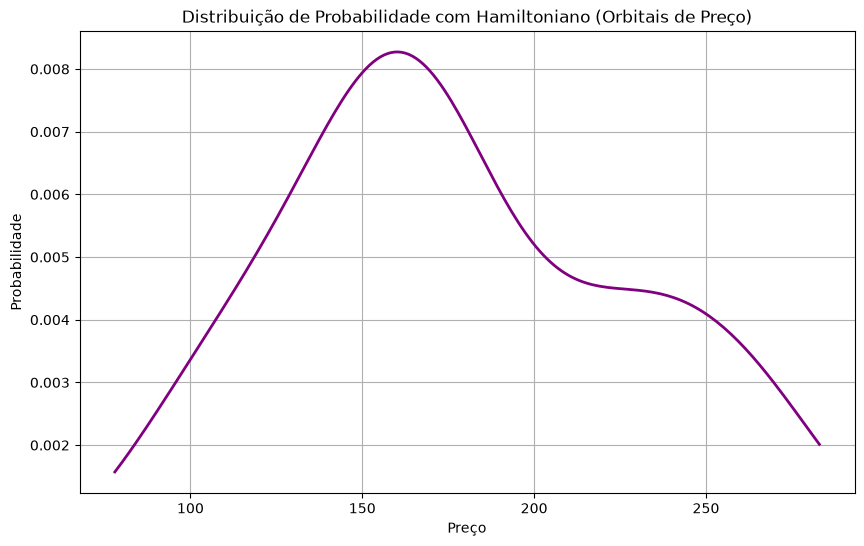

In [581]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

#Distribuição de Probabilidade com Hamiltoniano (Orbitais de Preço)
def price_probability_distribution_kde_hamiltonian(orders):
    prices = np.array([o["price"] for o in orders])
    volumes = np.array([o["volume"] for o in orders])

    # Energias
    kinetic = calculate_kinetic_energy(orders)
    potential = calculate_Potential_energy(orders)
    hamiltonian = np.array([k + p for k, p in zip(kinetic, potential)])

    # Pesos = volume * energia
    weights = volumes[:len(hamiltonian)] * hamiltonian

    # Estimativa de densidade com pesos
    kde = gaussian_kde(prices[:len(weights)], weights=weights)
    x_grid = np.linspace(prices.min(), prices.max(), 200)
    probabilities = kde(x_grid)

    # Normalizar
    probabilities /= probabilities.sum()

    return x_grid, probabilities

# Calcular distribuição suave com Hamiltoniano
x_grid, probabilities = price_probability_distribution_kde_hamiltonian(orders)

# Plotar
plt.figure(figsize=(10,6))
plt.plot(x_grid, probabilities, color="purple", linewidth=2)
plt.title("Distribuição de Probabilidade com Hamiltoniano (Orbitais de Preço)")
plt.xlabel("Preço")
plt.ylabel("Probabilidade")
plt.grid(True)
plt.show()


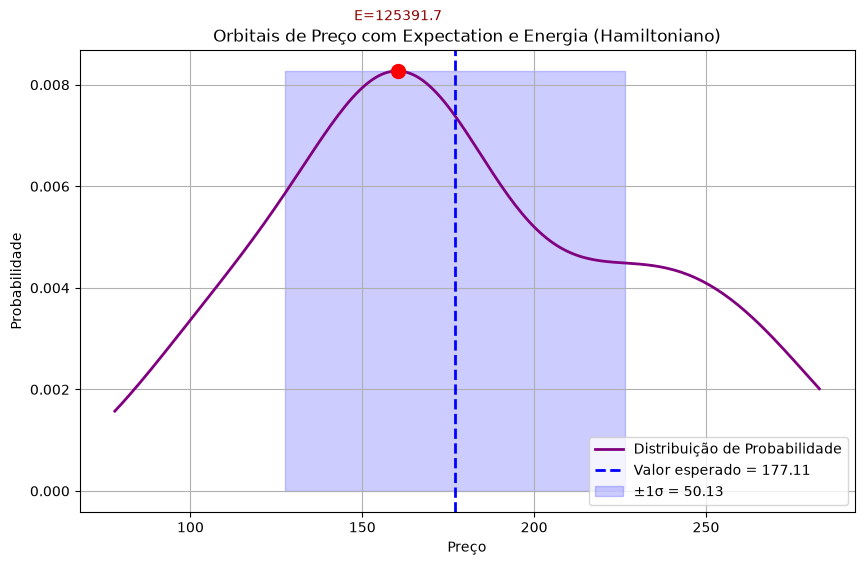

Picos detectados (orbitais de preço):
Preço ~ 160.41, Probabilidade ~ 0.0083, Energia média ~ 125391.69


In [582]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def expectation_and_variance(x_grid, probabilities):
    expectation = np.sum(x_grid * probabilities)
    variance = np.sum(((x_grid - expectation) ** 2) * probabilities)
    std_dev = np.sqrt(variance)
    return expectation, variance, std_dev

# Calcular expectation e variância
expectation, variance, std_dev = expectation_and_variance(x_grid, probabilities)

# Detectar picos locais
peaks, _ = find_peaks(probabilities)
peak_prices = x_grid[peaks]
peak_probs = probabilities[peaks]

# Calcular Hamiltoniano médio em torno de cada pico
kinetic = calculate_kinetic_energy(orders)
potential = calculate_Potential_energy(orders)
hamiltonian = np.array([k + p for k, p in zip(kinetic, potential)])
prices = np.array([o["price"] for o in orders])

# Garantir alinhamento
n = min(len(prices), len(hamiltonian))
prices = prices[:n]
hamiltonian = hamiltonian[:n]

peak_energies = []
for p in peak_prices:
    # Janela de ±5% em torno do pico
    mask = (prices >= p*0.95) & (prices <= p*1.05)
    if mask.sum() > 0:
        avg_energy = hamiltonian[mask].mean()
    else:
        avg_energy = 0
    peak_energies.append(avg_energy)




# Plotar
plt.figure(figsize=(10,6))
plt.plot(x_grid, probabilities, color="purple", linewidth=2, label="Distribuição de Probabilidade")

# Valor esperado
plt.axvline(expectation, color="blue", linestyle="--", linewidth=2, label=f"Valor esperado = {expectation:.2f}")

# Faixa ±1σ
plt.fill_between(x_grid, 0, probabilities.max(),
                 where=(x_grid >= expectation - std_dev) & (x_grid <= expectation + std_dev),
                 color="blue", alpha=0.2, label=f"±1σ = {std_dev:.2f}")

# Picos locais com energia
for p, prob, energy in zip(peak_prices, peak_probs, peak_energies):
    plt.scatter(p, prob, color="red", s=100, zorder=5)
    plt.text(p, prob+0.001, f"E={energy:.1f}", ha="center", color="darkred")

plt.title("Orbitais de Preço com Expectation e Energia (Hamiltoniano)")
plt.xlabel("Preço")
plt.ylabel("Probabilidade")
plt.legend()
plt.grid(True)
plt.show()

print("Picos detectados (orbitais de preço):")
for p, prob, energy in zip(peak_prices, peak_probs, peak_energies):
    print(f"Preço ~ {p:.2f}, Probabilidade ~ {prob:.4f}, Energia média ~ {energy:.2f}")


Região [111.36 - 213.58] (pico ~ 162.47) -> Energia média=49623.13, P(tunelamento resistência)=0.1168, P(tunelamento suporte)=1.0000


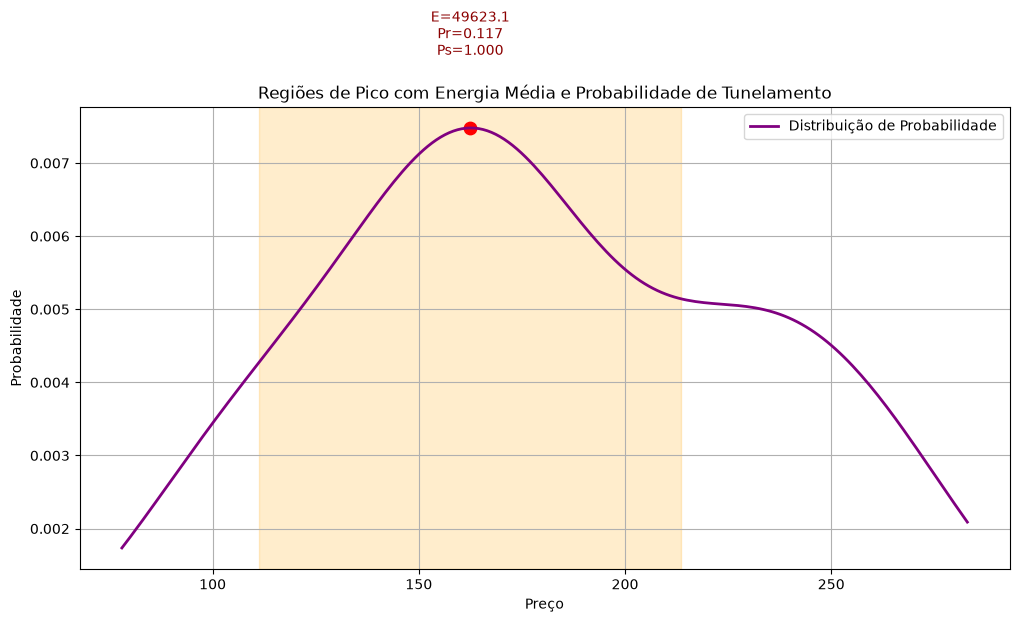

In [535]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Simular a probabilidade de o preço “atravessar” uma barreira de suporte ou resistência mesmo sem energia suficiente.
def tunneling_probability(H, barrier, alpha=0.00005):
    if H >= barrier:
        return 1.0
    else:
        deltaE = barrier - H
        return np.exp(-alpha * deltaE)

# Expectation e variância (Existe 2 ,deve depois remover o antigo)
def expectation_and_variance(x_grid, probabilities):
    expectation = np.sum(x_grid * probabilities)
    variance = np.sum(((x_grid - expectation) ** 2) * probabilities)
    std_dev = np.sqrt(variance)
    return expectation, variance, std_dev

expectation, variance, std_dev = expectation_and_variance(x_grid, probabilities)

# Detectar picos locais
peaks, _ = find_peaks(probabilities)
peak_prices = x_grid[peaks]
peak_probs = probabilities[peaks]

# Calcular Hamiltoniano
kinetic = calculate_kinetic_energy(orders)
potential = calculate_Potential_energy(orders)
hamiltonian = np.array([k + p for k, p in zip(kinetic, potential)])
prices = np.array([o["price"] for o in orders])

# Alinhar arrays
n = min(len(prices), len(hamiltonian))
prices = prices[:n]
hamiltonian = hamiltonian[:n]

# Definir barreiras (exemplo)
barrier_resistencia = np.percentile(hamiltonian, 90)
barrier_suporte = np.percentile(hamiltonian, 10)

# Calcular energia média e probabilidade de tunelamento por região
peak_regions = []
for p in peak_prices:
    # Janela de ±1σ em torno do pico
    mask = (prices >= p - std_dev) & (prices <= p + std_dev)
    if mask.sum() > 0:
        avg_energy_region = hamiltonian[mask].mean()
        prob_resistencia = tunneling_probability(avg_energy_region, barrier_resistencia)
        prob_suporte = tunneling_probability(avg_energy_region, barrier_suporte)
    else:
        avg_energy_region, prob_resistencia, prob_suporte = 0, 0, 0
    
    peak_regions.append({
        "preco_pico": p,
        "prob_pico": probabilities[np.argmin(np.abs(x_grid - p))],
        "preco_min": p - std_dev,
        "preco_max": p + std_dev,
        "energia_media": avg_energy_region,
        "P_resistencia": prob_resistencia,
        "P_suporte": prob_suporte
    })

# Imprimir resultados
for r in peak_regions:
    print(f"Região [{r['preco_min']:.2f} - {r['preco_max']:.2f}] "
          f"(pico ~ {r['preco_pico']:.2f}) -> Energia média={r['energia_media']:.2f}, "
          f"P(tunelamento resistência)={r['P_resistencia']:.4f}, "
          f"P(tunelamento suporte)={r['P_suporte']:.4f}")

# Plotar gráfico
plt.figure(figsize=(12,6))
plt.plot(x_grid, probabilities, color="purple", linewidth=2, label="Distribuição de Probabilidade")

# Marcar regiões
for r in peak_regions:
    plt.axvspan(r["preco_min"], r["preco_max"], color="orange", alpha=0.2)
    plt.scatter(r["preco_pico"], r["prob_pico"], color="red", s=80)
    plt.text(r["preco_pico"], r["prob_pico"]+0.001,
             f"E={r['energia_media']:.1f}\nPr={r['P_resistencia']:.3f}\nPs={r['P_suporte']:.3f}",
             ha="center", color="darkred")

plt.title("Regiões de Pico com Energia Média e Probabilidade de Tunelamento")
plt.xlabel("Preço")
plt.ylabel("Probabilidade")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Colapso da função de onda

def collapse_wave_function(evolution_series):
    print('evolution_series',evolution_series)
    collapsed_series = []
    for e in evolution_series:
        # Evento forte: Hamiltoniano acima do limiar
        if e["H"] <= 100 and e["psi_buy"] > 0.50:
            # Colapso para estado de compra
            buy, sell = 1.0, 0.0
        elif e["H"] <= 100 and e["psi_sell"] < 0.50:
            # Colapso para estado de venda
            buy, sell = 0.0, 1.0
        else:
            # Mantém valores originais
            buy, sell = e["psi_buy"], e["psi_sell"]

        collapsed_series.append({
            "ordem": e["ordem"],
            "buy": buy,
            "sell": sell,
            "H": e["H"]
        })
    return collapsed_series

# Exemplo: colapsar quando H > 200000
collapsed = collapse_wave_function(evolution_series)

# Mostrar resultados
for c in collapsed[:10]:
    print(f"Ordem {c['ordem']}: Ψ_buy={c['buy']:.2f}, Ψ_sell={c['sell']:.2f}, H={c['H']:.2f}")


evolution_series [{'ordem': 1, 'psi_buy': np.float64(0.502106976355778), 'psi_sell': np.float64(0.4978930236442221), 'H': 26143.29413105846, 'oscillation': np.float64(0.0)}, {'ordem': 2, 'psi_buy': np.float64(0.5011369982636937), 'psi_sell': np.float64(0.4988630017363063), 'H': 12396.986613147255, 'oscillation': np.float64(0.014776010333066978)}, {'ordem': 3, 'psi_buy': np.float64(0.508141234483656), 'psi_sell': np.float64(0.491858765516344), 'H': 21595.950068449383, 'oscillation': np.float64(0.02823212366975177)}, {'ordem': 4, 'psi_buy': np.float64(0.5009700437668078), 'psi_sell': np.float64(0.49902995623319224), 'H': 65904.53866822932, 'oscillation': np.float64(0.03916634548137417)}, {'ordem': 5, 'psi_buy': np.float64(0.49354587479375617), 'psi_sell': np.float64(0.5064541252062438), 'H': 56873.69800241598, 'oscillation': np.float64(0.046601954298361316)}, {'ordem': 6, 'psi_buy': np.float64(0.5167028805795014), 'psi_sell': np.float64(0.4832971194204986), 'H': 6655.9534083261415, 'osci